## Dataset

This project uses the **Stroke Prediction Dataset** from Kaggle.

Source:  
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset


## Setup

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import itertools
from scipy.stats import chi2_contingency

In [ ]:
RANDOM_STATE = 9
np.random.seed(RANDOM_STATE)

sns.set_theme(style="white", palette='bright')

In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

# Update if necessary
df = pd.read_csv("../data/stroke-data.csv")
df.head()

Mounted at /content/drive


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Overview


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']

In [ ]:
round(df[num_cols].describe(), 2)

,age,avg_glucose_level,bmi
count,5110.00,5110.00,4909.00
mean,43.23,106.15,28.89
std,22.61,45.28,7.85
min,0.08,55.12,10.30
25%,25.00,77.24,23.50
50%,45.00,91.88,28.10
75%,61.00,114.09,33.10
max,82.00,271.74,97.60


In [ ]:
for col in cat_cols:
    print(round(df[col].value_counts() / df[col].count(), 2), "\n")

gender
Female    0.59
Male      0.41
Other     0.00
Name: count, dtype: float64 

hypertension
0    0.9
1    0.1
Name: count, dtype: float64 

heart_disease
0    0.95
1    0.05
Name: count, dtype: float64 

ever_married
Yes    0.66
No     0.34
Name: count, dtype: float64 

work_type
Private          0.57
Self-employed    0.16
children         0.13
Govt_job         0.13
Never_worked     0.00
Name: count, dtype: float64 

Residence_type
Urban    0.51
Rural    0.49
Name: count, dtype: float64 

smoking_status
never smoked       0.37
Unknown            0.30
formerly smoked    0.17
smokes             0.15
Name: count, dtype: float64 

stroke
0    0.95
1    0.05
Name: count, dtype: float64 



## Checks

In [ ]:
print(df.duplicated().sum())
print(len(df['id'].unique()))

0
5110


In [ ]:
df[df['gender'] == 'Other']

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26.0,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [ ]:
print(df[df['work_type'] == 'children']['age'].max())
print(df[df['ever_married'] == 'Yes']['age'].min())
print(df[df['work_type'] == 'Never_worked']['age'].describe()[['min', 'max']])

16.0
18.0
min    13.0
max    23.0
Name: age, dtype: float64


### Missing Values

In [ ]:
bmi_na_sum = df['bmi'].isna().sum()

print(bmi_na_sum)
print(round(bmi_na_sum / df.shape[0], 2))

201
0.04


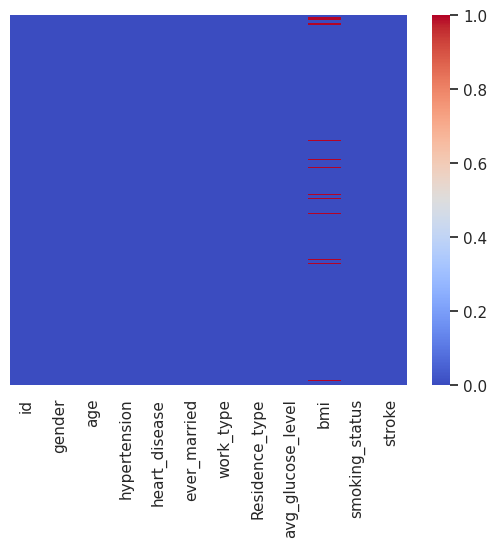

In [ ]:
sns.heatmap(df.isna(), cmap='coolwarm', yticklabels=False)
plt.show()

In [ ]:
df_na_filtered = df[df['bmi'].isna()]

In [ ]:
round(df_na_filtered[num_cols].describe(), 2)

,age,avg_glucose_level,bmi
count,201.00,201.00,0.0
mean,52.05,126.72,NaN
std,22.28,59.24,NaN
min,0.48,57.52,NaN
25%,37.00,81.43,NaN
50%,58.00,99.87,NaN
75%,71.00,191.79,NaN
max,82.00,260.85,NaN


In [ ]:
for col in cat_cols:
    print(round(df_na_filtered[col].value_counts() / df_na_filtered[col].count(), 2), "\n")

gender
Male      0.52
Female    0.48
Name: count, dtype: float64 

hypertension
0    0.77
1    0.23
Name: count, dtype: float64 

heart_disease
0    0.84
1    0.16
Name: count, dtype: float64 

ever_married
Yes    0.74
No     0.26
Name: count, dtype: float64 

work_type
Private          0.57
Self-employed    0.22
Govt_job         0.13
children         0.08
Name: count, dtype: float64 

Residence_type
Urban    0.53
Rural    0.47
Name: count, dtype: float64 

smoking_status
Unknown            0.30
smokes             0.26
formerly smoked    0.24
never smoked       0.20
Name: count, dtype: float64 

stroke
0    0.8
1    0.2
Name: count, dtype: float64 



## Univariate Analysis

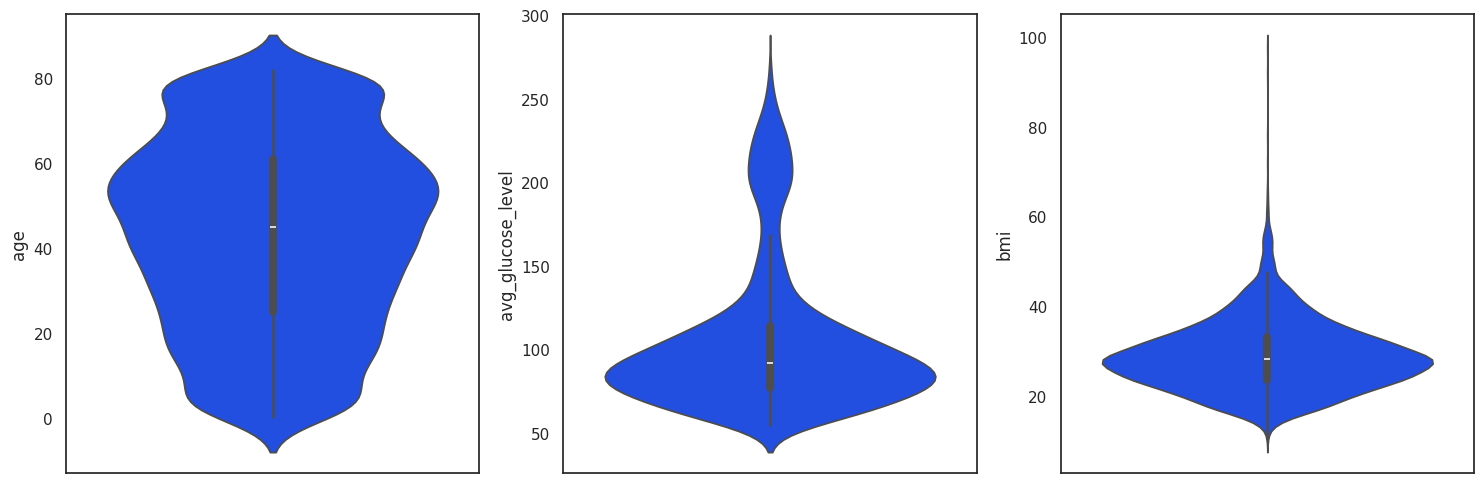

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_cols):
    sns.violinplot(y=df[col], ax=ax)

plt.tight_layout()
plt.show()

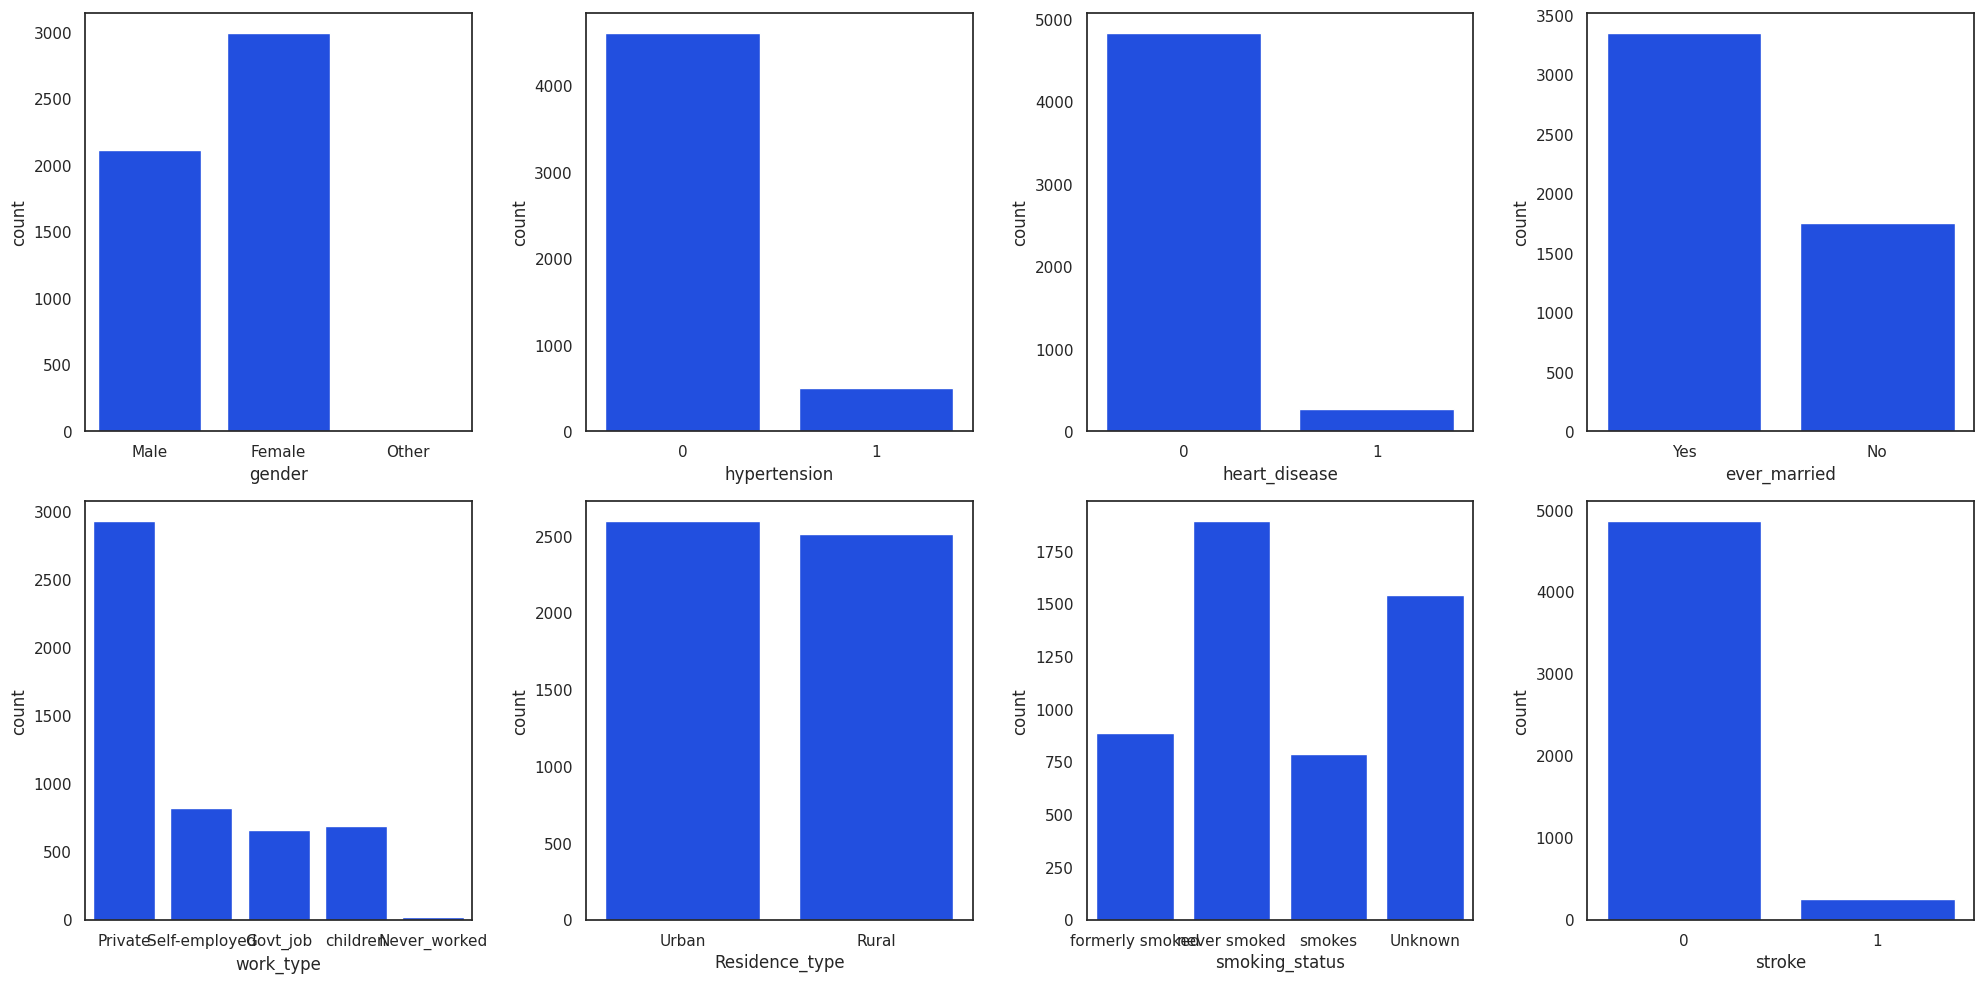

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax)

plt.tight_layout()
plt.show()

## Multivariate Analysis

### Numeric - Numeric

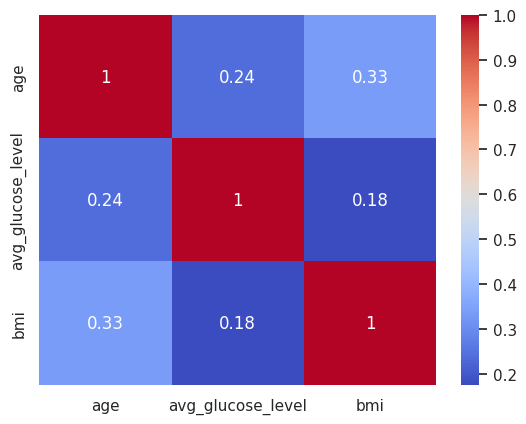

In [ ]:
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True)
plt.show()

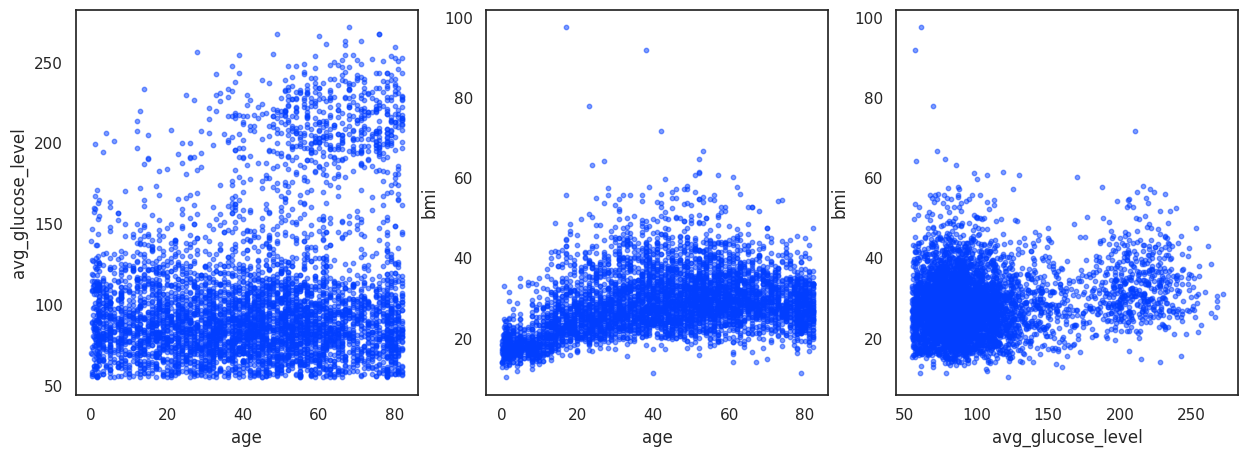

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, (x_col, y_col) in zip(axes, itertools.combinations(num_cols, 2)):
    ax.scatter(df[x_col], df[y_col], s=10, alpha=0.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

plt.show()

### Numeric - Categoric

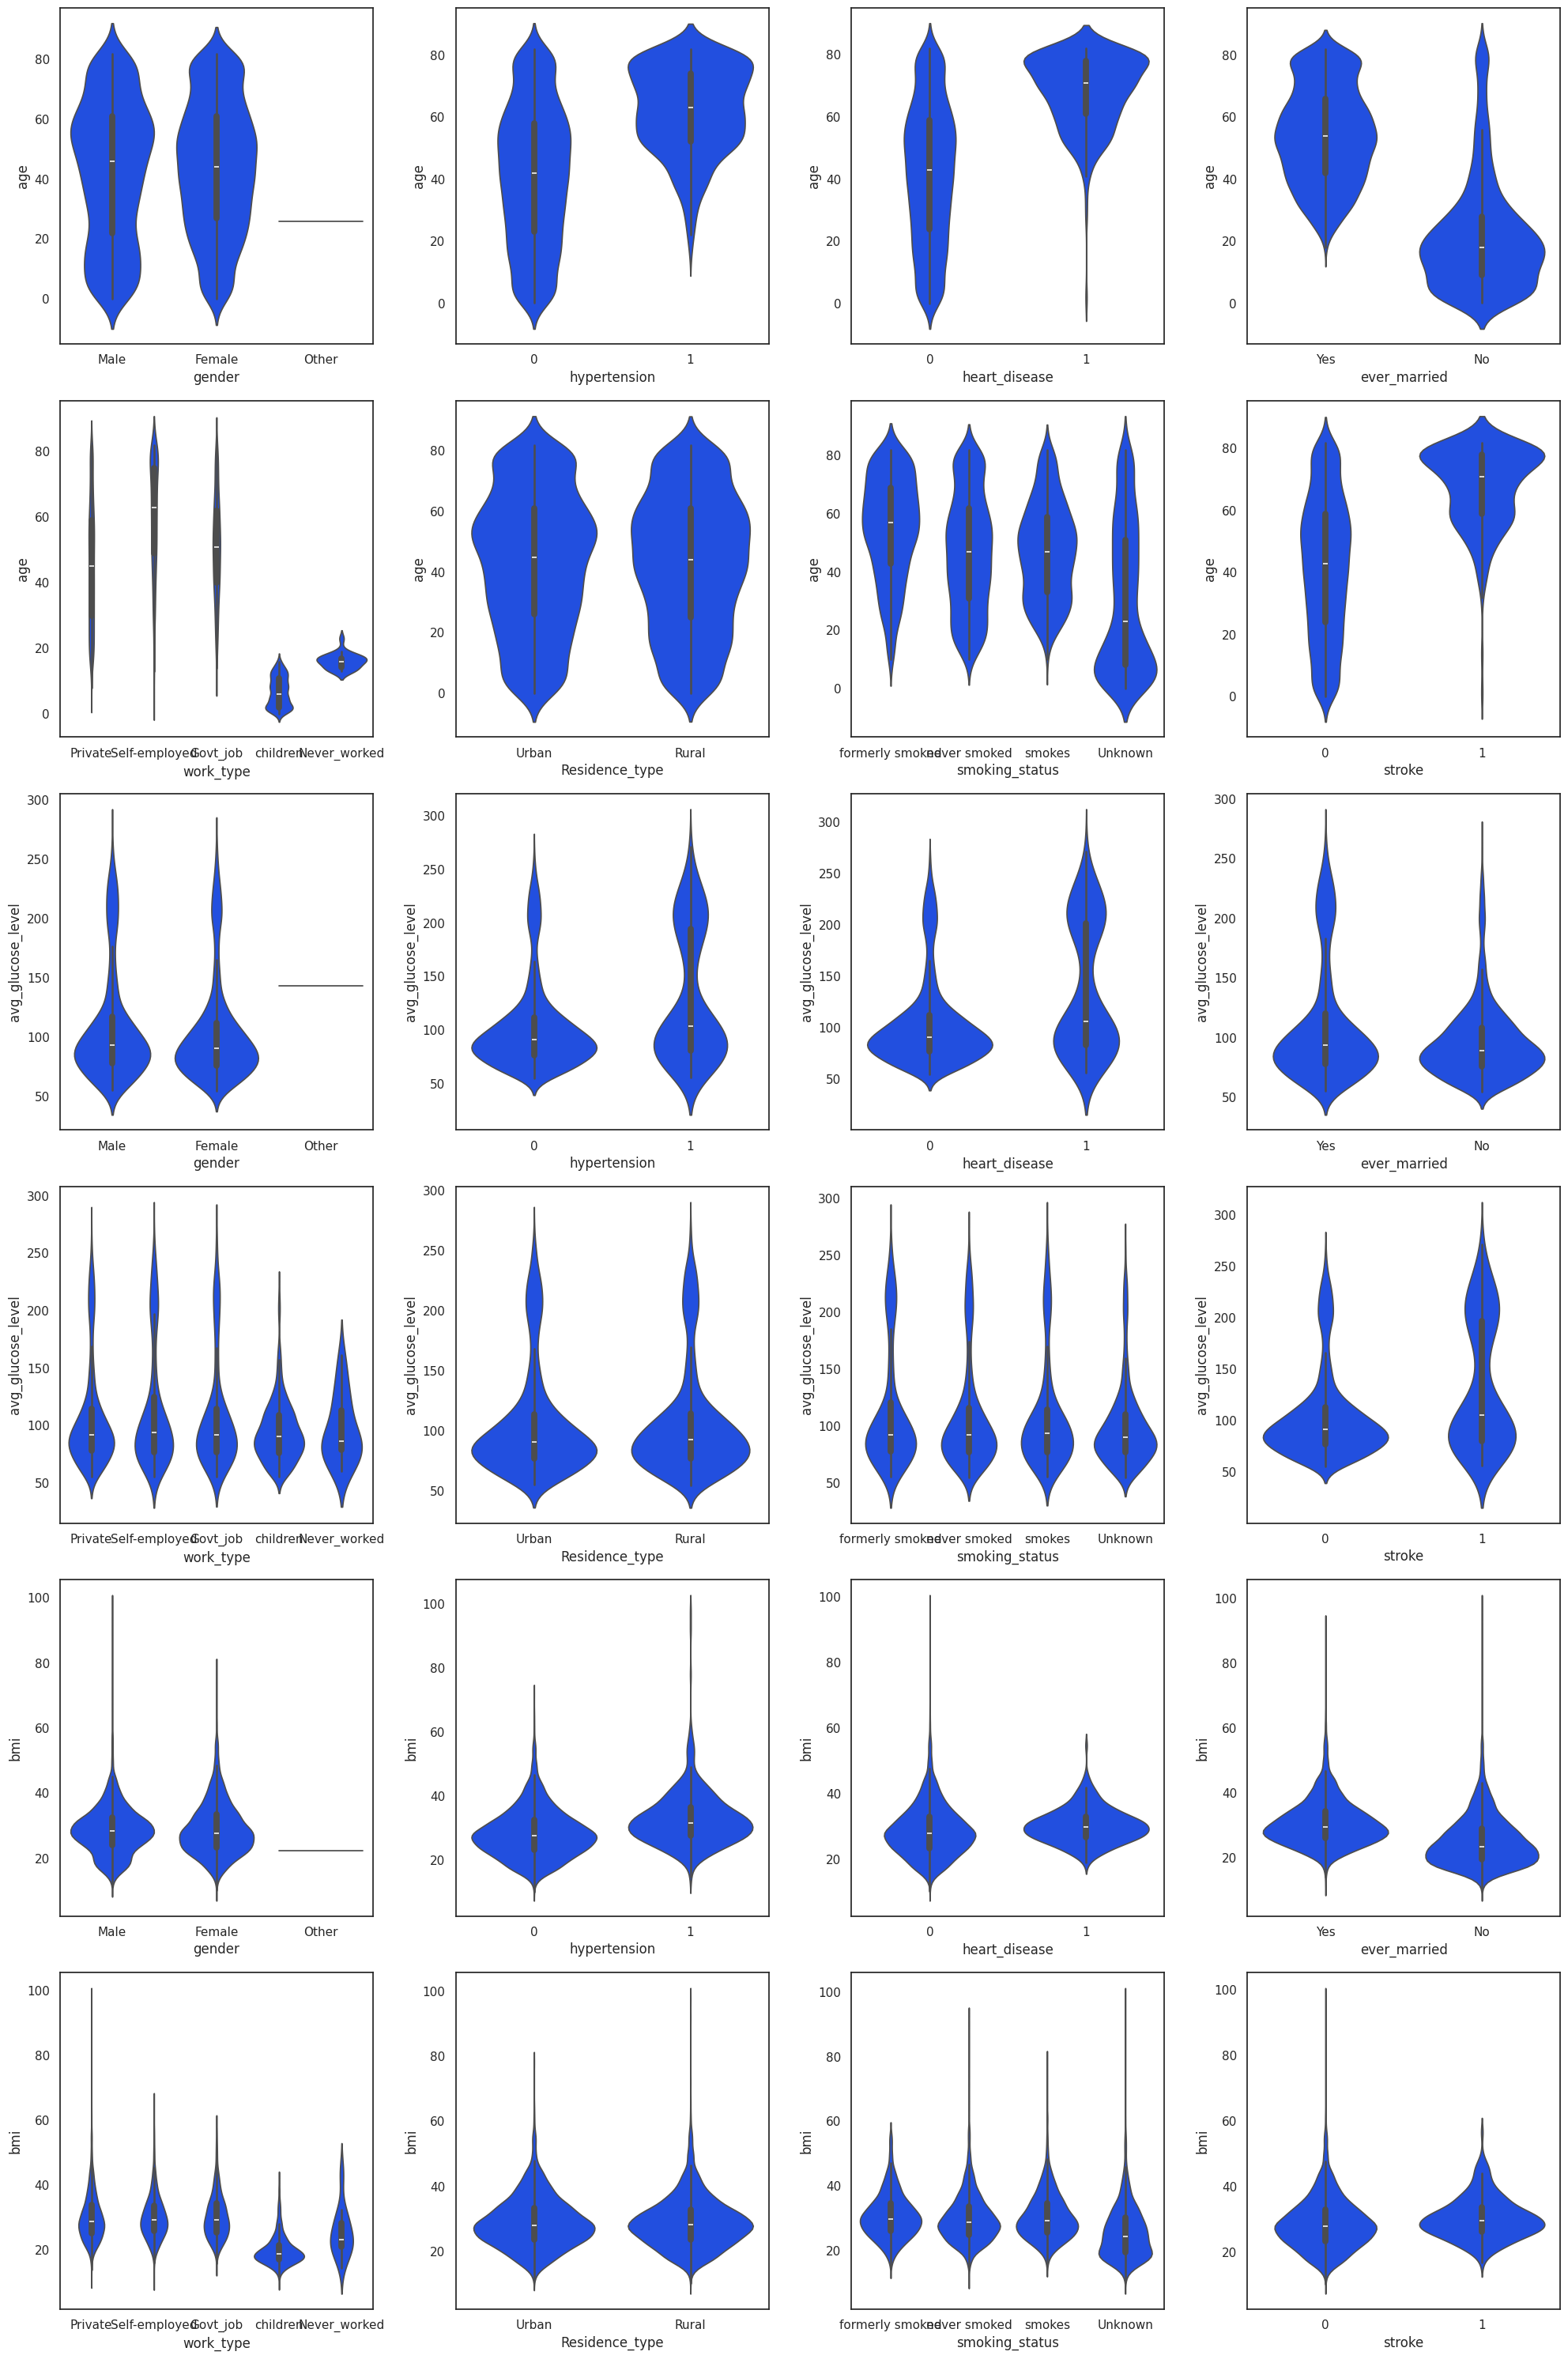

In [ ]:
num_cat_combos = [(num, cat) for num in num_cols for cat in cat_cols]

fig, axes = plt.subplots(6, 4, figsize=(20,30))
axes = axes.flatten()

for i, (num, cat) in enumerate(num_cat_combos):
    sns.violinplot(x=cat, y=num, data=df, ax=axes[i])

plt.tight_layout()
plt.show()

In [ ]:
print(df[df['heart_disease']==1]['age'].min())

2.0


In [ ]:
print(len(df.loc[(df['age'] < 17) & (df['work_type'] == 'Never_worked')]))
print(len(df.loc[(df['age'] < 17) & (df['work_type'] == 'children')]))
print(len(df.loc[(df['age'] < 17) & (~df['work_type'].isin(['Never_worked', 'children']))]))

12
687
97


In [ ]:
df.loc[(df['age'] < 17) & (df['work_type'] == 'Never_worked')]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
253,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,Unknown,0
939,16556,Male,13.0,0,0,No,Never_worked,Rural,111.48,20.8,Unknown,0
1789,13862,Female,13.0,0,0,No,Never_worked,Urban,70.93,22.9,never smoked,0
1922,51935,Male,16.0,0,0,No,Never_worked,Urban,59.99,28.2,never smoked,0
2346,61219,Female,14.0,0,0,No,Never_worked,Urban,148.37,22.7,never smoked,0
2740,28461,Male,15.0,0,0,No,Never_worked,Rural,79.59,28.4,Unknown,0
2781,23587,Female,16.0,0,0,No,Never_worked,Urban,84.40,25.9,never smoked,0
3196,57274,Male,14.0,0,0,No,Never_worked,Urban,137.91,41.8,never smoked,0
3972,69559,Male,15.0,0,0,No,Never_worked,Urban,64.29,16.7,Unknown,0
4068,28734,Female,16.0,0,0,No,Never_worked,Urban,102.10,27.1,never smoked,0


### Categoric - Categoric

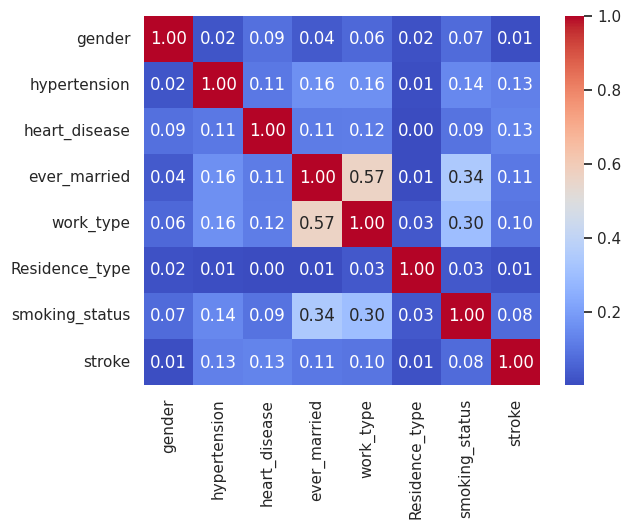

In [ ]:
def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    k = min(cm.shape) - 1
    return np.sqrt(chi2 / (n * k)) if k > 0 else 0

assoc_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i:]:
        v = cramers_v(df[col1], df[col2]) if col1 != col2 else 1.0
        assoc_matrix.loc[col1, col2] = v
        assoc_matrix.loc[col2, col1] = v

sns.heatmap(assoc_matrix, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

In [ ]:
for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:
        print("=" * 50)
        print(f"{col1} v {col2}\n")

        counts = pd.crosstab(df[col1], df[col2])
        print("Counts:")
        print(counts)

        props = pd.crosstab(df[col1], df[col2], normalize='index').round(2)
        print("\nRow proportions:")
        print(props)
        print("\n")

gender v hypertension

Counts:
hypertension     0    1
gender                 
Female        2718  276
Male          1893  222
Other            1    0

Row proportions:
hypertension     0     1
gender                  
Female        0.91  0.09
Male          0.90  0.10
Other         1.00  0.00


gender v heart_disease

Counts:
heart_disease     0    1
gender                  
Female         2881  113
Male           1952  163
Other             1    0

Row proportions:
heart_disease     0     1
gender                   
Female         0.96  0.04
Male           0.92  0.08
Other          1.00  0.00


gender v ever_married

Counts:
ever_married   No   Yes
gender                 
Female        993  2001
Male          763  1352
Other           1     0

Row proportions:
ever_married    No   Yes
gender                  
Female        0.33  0.67
Male          0.36  0.64
Other         1.00  0.00


gender v work_type

Counts:
work_type  Govt_job  Never_worked  Private  Self-employed  children
gende

## Summary & Findings

### Data Cleaning Decisions

- `id` column provides no predictive value → will be dropped.
- `gender = 'Other'` contains only one observation → remove due to negligible representation.
- Standardise `work_type`:
  - Rename `"children"` → `"child"`.
  - If `age < 17` and `work_type = "Never_worked"` → reassign to `"child"`.
- Target variable (`stroke`) is highly imbalanced.


### Missing Data

- `bmi` appears MNAR:
  - ~20% of rows with missing `bmi` are stroke-positive,
  - compared to ~5% stroke prevalence in the overall dataset.
- Create `bmi_missing` indicator feature to preserve potential predictive signal from missingness.
- Impute `bmi` values (median) in pipeline

### Feature Relationships & Patterns

- Stronger stroke signal observed for `age`.

- Higher `age` is associated with increased:
  - `hypertension`
  - `heart_disease`

- Younger individuals more likely to have `"Unknown"` smoking status.

- 41% of females vs 31% of males report never smoking.

- 29% of individuals with hypertension are self-employed vs 15% without hypertension.

- Higher proportion of smokers among those with heart disease.

- Self-employment is more common among married individuals.